In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import cv2
import zipfile
import numpy as np
from sklearn.model_selection import train_test_split

In [4]:
# Extract the dataset
zip_path = "/content/brain.zip"
extract_path = "/content/extracted_images"
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

# Load Brain Tumor dataset
images = []
labels = []
categories = ['no', 'yes'] # 0 = no tumor, 1 = tumor

for label, category in enumerate(categories):
    folder = os.path.join(extract_path, category)
    if os.path.exists(folder):
        for file in os.listdir(folder):
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Read in grayscale like MNIST
            if img is not None:
                img = cv2.resize(img, (64, 64)) # Resize all images to 64x64
                images.append(img)
                labels.append(label)

X = np.array(images)
y = np.array(labels)

# Split into train and test sets (like x_train, y_train, x_test, y_test)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Normalise Data (scaling pixel values to range 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

In [6]:
# Reshape data to include channel dimension (64, 64, 1)
x_train = x_train.reshape(-1, 64, 64, 1)
x_test = x_test.reshape(-1, 64, 64, 1)

In [7]:
# Define CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # 1 output for Yes/No (Binary)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Compiler Model
model.compile(optimizer='adam',
              loss='binary_crossentropy', # Changed for Yes/No output
              metrics=['accuracy'])

# Train model
model.fit(x_train, y_train, epochs=15,validation_data=(x_test, y_test))

# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.6139 - loss: 0.6750 - val_accuracy: 0.7843 - val_loss: 0.5239
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.7822 - loss: 0.5186 - val_accuracy: 0.8039 - val_loss: 0.5015
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.7921 - loss: 0.4785 - val_accuracy: 0.7647 - val_loss: 0.4709
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.7921 - loss: 0.4507 - val_accuracy: 0.8039 - val_loss: 0.4640
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.8218 - loss: 0.4130 - val_accuracy: 0.8039 - val_loss: 0.5019
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.8416 - loss: 0.3577 - val_accuracy: 0.8039 - val_loss: 0.4906
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.8614 - loss: 0.3703 - val_accuracy: 0.7059 - val_loss: 0.5199
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.8762 - loss: 0.3042 - val_accuracy: 0.7843 - val_loss: 0.

In [9]:
# Predict on test images
predictions = model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


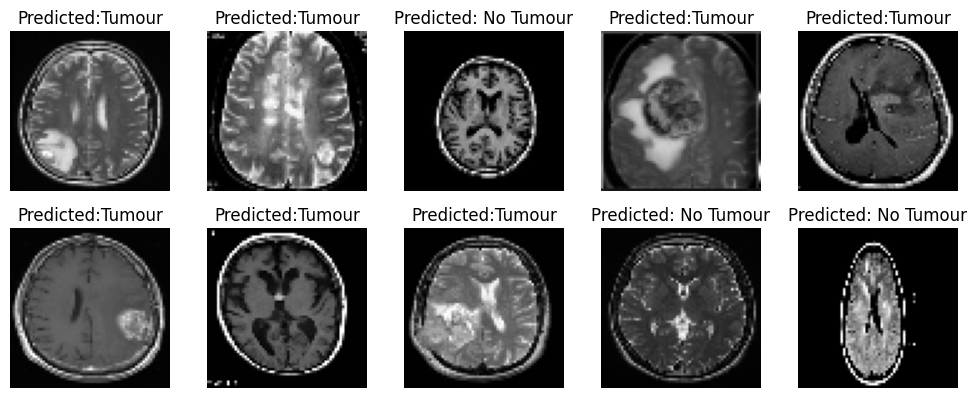

In [10]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i].reshape(64,64), cmap='gray')

    # Logic for Brain Tumor: if probability > 0.5, it's 1 (Yes). Otherwise 0 (No).
    pred_val=1 if predictions[i][0] > 0.5 else 0
    if pred_val == 1:
        plt.title("Predicted:Tumour")
    else:
        plt.title("Predicted: No Tumour")
    plt.axis('off')
plt.tight_layout()
plt.show()